# Linear Regression From Scratch (Gradient Descent)
This notebook demonstrates how to implement **Linear Regression from scratch using Gradient Descent**. We load a dataset, visualize it, define the loss function, and train a model.

## 1. Import Required Libraries
We import NumPy for numerical operations, Pandas for data handling, and Matplotlib for visualization.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## 2. Load the Dataset
We load a CSV dataset that contains two columns:
- `hours_studied`
- `exam_score`

In [2]:
data = pd.read_csv('data.csv')
print(data.head())

   student_id   name          course  hours_studied  attendance_percent  \
0           1   Sara            Math              9                  75   
1           2  Marta            Math             18                  65   
2           3   Ruth            Math              1                  65   
3           4  Dawit  Linear Algebra             20                  61   
4           5  Dawit  Linear Algebra             14                  74   

   exam_score  
0          64  
1          87  
2          63  
3          85  
4          78  


## 3. Extract Features and Target
`x` represents the input feature (hours studied) and `y` represents the target variable (exam score).

In [3]:
x = data['hours_studied'].values
y = data['exam_score'].values

## 4. Visualize the Dataset
We create a scatter plot to understand the relationship between study hours and exam scores.

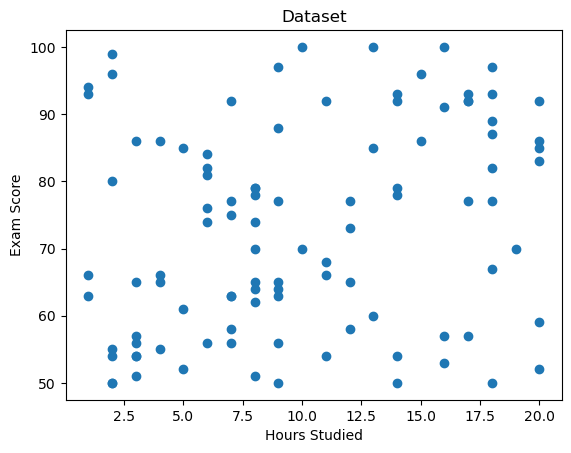

In [4]:
plt.scatter(x, y)
plt.xlabel('Hours Studied')
plt.ylabel('Exam Score')
plt.title('Dataset')
plt.show()

## 5. Define the Loss Function
The loss function measures how far our predictions are from the true values.
We use **Mean Squared Error (MSE)**.

In [5]:
def loss_function(m, b, x, y):
    total_loss = 0
    N = len(x)

    for i in range(N):
        y_pred = m * x[i] + b
        total_loss += (y_pred - y[i]) ** 2

    return total_loss / N

## 6. Implement Gradient Descent
Gradient Descent updates the slope `m` and intercept `b` to minimize the loss.

In [6]:
def gradient_descent(m, b, x, y, learning_rate):
    m_gradient = 0
    b_gradient = 0
    N = len(x)

    for i in range(N):
        y_pred = m * x[i] + b

        m_gradient += -(2/N) * x[i] * (y[i] - y_pred)
        b_gradient += -(2/N) * (y[i] - y_pred)

    step_size_slope = learning_rate * m_gradient
    step_size_intercept = learning_rate * b_gradient

    m -= step_size_slope
    b -= step_size_intercept

    return m, b

## 7. Train the Model
We initialize the parameters and run gradient descent for multiple epochs.

In [7]:
m = 0
b = 0
learning_rate = 0.0001
epochs = 1000

for i in range(epochs):
    m, b = gradient_descent(m, b, x, y, learning_rate)

    if i % 100 == 0:
        loss = loss_function(m, b, x, y)
        print(f'Epoch {i}, Loss: {loss}')

print('Final parameters:')
print('m =', m)
print('b =', b)

Epoch 0, Loss: 5326.105929717317
Epoch 100, Loss: 1314.2890489990107
Epoch 200, Loss: 1285.4818347418397
Epoch 300, Loss: 1274.8600837737563
Epoch 400, Loss: 1264.4248072246262
Epoch 500, Loss: 1254.093270907179
Epoch 600, Loss: 1243.8640799964744
Epoch 700, Loss: 1233.7362189967575
Epoch 800, Loss: 1223.7086841309392
Epoch 900, Loss: 1213.780481572832
Final parameters:
m = 5.38896412321231
b = 3.622313442261826


## 8. Plot the Regression Line
Finally, we visualize the trained regression line along with the original dataset.

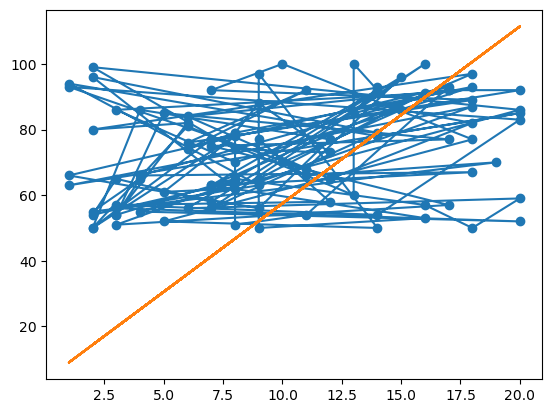

In [8]:
y_pred = m * x + b

plt.scatter(x, y)
plt.plot(x, y)
plt.plot(x, y_pred)
plt.show()